In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_main_continuum = pd.read_parquet("df_main_continuum.parquet")
df_holdout_continuum = pd.read_parquet("df_holdout_continuum.parquet")

In [3]:
def add_physics_features(df):
    df = df.copy()

    magic = np.array([2, 8, 20, 28, 50, 82, 126])

    # ratio / asymmetry features
    df["N_over_Z"] = df["N"] / df["Z"].replace(0, np.nan)
    df["A_over_Z"] = df["A"] / df["Z"].replace(0, np.nan)
    df["N_minus_Z"] = df["N"] - df["Z"]
    df["neutron_excess"] = (df["N"] - df["Z"]) / df["A"].replace(0, np.nan)

    # parity features
    df["Z_even"] = (df["Z"] % 2 == 0).astype(int)
    df["N_even"] = (df["N"] % 2 == 0).astype(int)
    df["A_even"] = (df["A"] % 2 == 0).astype(int)
    df["is_even_even"] = ((df["Z"] % 2 == 0) & (df["N"] % 2 == 0)).astype(int)
    df["is_odd_odd"] = ((df["Z"] % 2 == 1) & (df["N"] % 2 == 1)).astype(int)

    # shell / magic-number features
    df["dist_Z_magic"] = df["Z"].apply(lambda z: np.min(np.abs(magic - z)))
    df["dist_N_magic"] = df["N"].apply(lambda n: np.min(np.abs(magic - n)))
    df["Z_magic"] = df["Z"].isin(magic).astype(int)
    df["N_magic"] = df["N"].isin(magic).astype(int)

    # separation-energy combinations
    df["S_1n_minus_S_1p"] = df["S_1n_MeV"] - df["S_1p_MeV"]
    df["S_2n_minus_S_2p"] = df["S_2n_MeV"] - df["S_2p_MeV"]
    df["S_2n_minus_2S_1n"] = df["S_2n_MeV"] - 2 * df["S_1n_MeV"]
    df["S_2p_minus_2S_1p"] = df["S_2p_MeV"] - 2 * df["S_1p_MeV"]

    # energy features
    if "Energy" in df.columns:
        pos = df["Energy"] > 0
        df.loc[pos, "inv_sqrt_E"] = 1.0 / np.sqrt(df.loc[pos, "Energy"])
        df.loc[pos, "sqrt_E"] = np.sqrt(df.loc[pos, "Energy"])

    return df

Train rows: 1548291
Val rows  : 242020
Train groups: 1729
Val groups  : 433
Shared groups: 0
MT in features? True

Linear-space metrics
RMSE: 3814.16
MAE : 57.4157
R²  : 0.0844971

Log-space metrics
RMSE: 0.54883
MAE : 0.333265
R²  : 0.567356


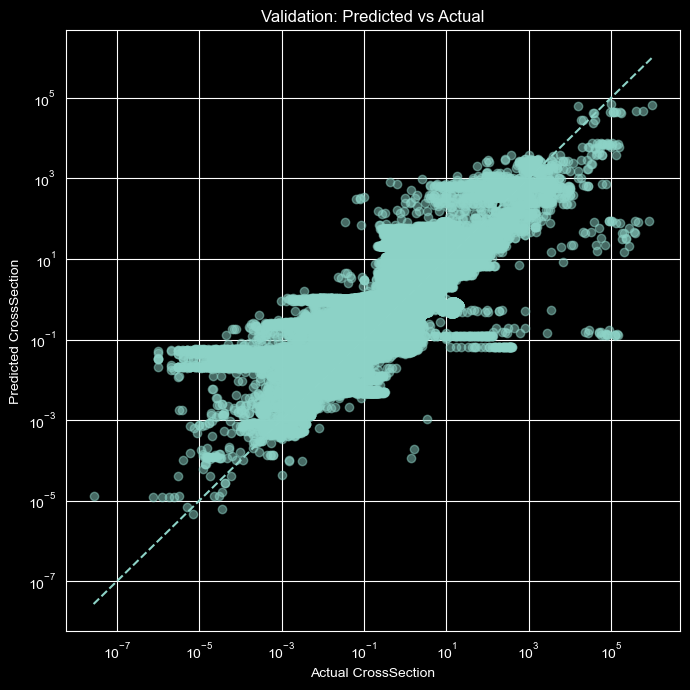

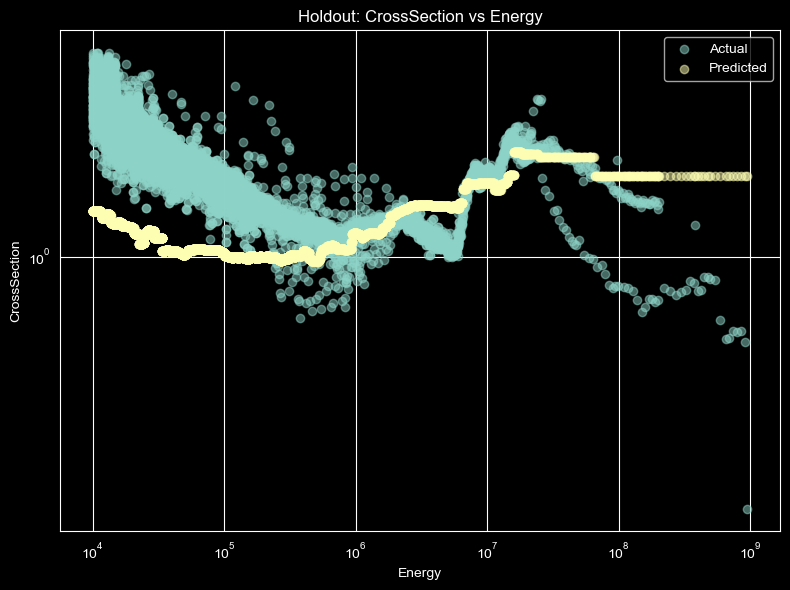


Top 20 feature importances:
Z_even                     0.219715
MT                         0.158287
out_g                      0.148494
N_minus_Z                  0.040687
out_f                      0.040351
N_even                     0.040075
S_2n_MeV                   0.035125
Z                          0.033491
N                          0.026557
Binding_Per_Nucleon_MeV    0.025395
A                          0.018177
S_1n_MeV                   0.017434
out_a                      0.014891
S_2p_minus_2S_1p           0.013868
N_over_Z                   0.013365
out_p                      0.011616
Binding_Energy_MeV         0.010100
S_2p_MeV                   0.010041
dist_Z_magic               0.008916
S_1p_MeV                   0.008559
dtype: float32


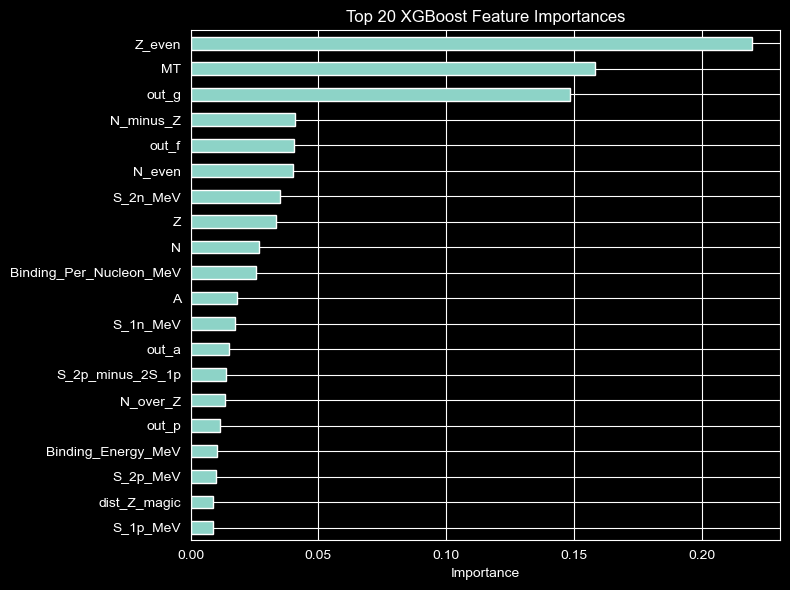

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --------------------------------------------------
# 1. Copy data
# --------------------------------------------------
df_train = df_main_continuum.copy()
df_holdout = df_holdout_continuum.copy()

df_train = add_physics_features(df_train)
df_holdout = add_physics_features(df_holdout)
# --------------------------------------------------
# 2. Keep only rows valid for log transforms
# --------------------------------------------------
df_train = df_train[(df_train["CrossSection"] > 0) & (df_train["Energy"] > 0)].copy()
df_holdout = df_holdout[df_holdout["Energy"] > 0].copy()

# --------------------------------------------------
# 3. Add log features / target
# --------------------------------------------------
df_train["log_CrossSection"] = np.log10(df_train["CrossSection"])
df_train["log_Energy"] = np.log10(df_train["Energy"])
df_holdout["log_Energy"] = np.log10(df_holdout["Energy"])

# --------------------------------------------------
# 4. Build grouping column using Z, A, MT
#    This is for splitting only
# --------------------------------------------------
group_cols = ["Z", "A", "MT"]
missing_group_cols = [c for c in group_cols if c not in df_train.columns]
if missing_group_cols:
    raise ValueError(f"Missing grouping columns in df_main_thermal: {missing_group_cols}")

df_train["group_key"] = (
        df_train["Z"].astype(str) + "_" +
        df_train["A"].astype(str) + "_" +
        df_train["MT"].astype(str)
)

groups = df_train["group_key"]

# --------------------------------------------------
# 5. Define features and target
#    MT is now INCLUDED in training
# --------------------------------------------------
target_col = "log_CrossSection"

cols_to_remove = [
    "Entry",
    "CrossSection",
    "Uncertainty",
    "log_CrossSection",
    "group_key"
]

X = df_train.drop(columns=cols_to_remove, errors="ignore").copy()
y = df_train[target_col].copy()

X_holdout = df_holdout.drop(
    columns=["Entry", "CrossSection", "Uncertainty"],
    errors="ignore"
).copy()

# --------------------------------------------------
# 6. One-hot encode categoricals if needed
# --------------------------------------------------
X = pd.get_dummies(X, drop_first=False)
X_holdout = pd.get_dummies(X_holdout, drop_first=False)

# Align holdout columns to training columns
X_holdout = X_holdout.reindex(columns=X.columns, fill_value=0)

# --------------------------------------------------
# 7. Group-based train/validation split
# --------------------------------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]
y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

train_groups = groups.iloc[train_idx]
val_groups = groups.iloc[val_idx]

print(f"Train rows: {len(X_train)}")
print(f"Val rows  : {len(X_val)}")
print(f"Train groups: {train_groups.nunique()}")
print(f"Val groups  : {val_groups.nunique()}")
print(f"Shared groups: {len(set(train_groups).intersection(set(val_groups)))}")
print("MT in features?", "MT" in X.columns)

# --------------------------------------------------
# 8. Train model
# --------------------------------------------------
model = XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# --------------------------------------------------
# 9. Validation predictions
# --------------------------------------------------
y_val_pred_log = model.predict(X_val)

y_val_true = 10 ** y_val
y_val_pred = 10 ** y_val_pred_log

print("\nLinear-space metrics")
print(f"RMSE: {mean_squared_error(y_val_true, y_val_pred) ** 0.5:.6g}")
print(f"MAE : {mean_absolute_error(y_val_true, y_val_pred):.6g}")
print(f"R²  : {r2_score(y_val_true, y_val_pred):.6g}")

print("\nLog-space metrics")
print(f"RMSE: {mean_squared_error(y_val, y_val_pred_log) ** 0.5:.6g}")
print(f"MAE : {mean_absolute_error(y_val, y_val_pred_log):.6g}")
print(f"R²  : {r2_score(y_val, y_val_pred_log):.6g}")

# --------------------------------------------------
# 10. Predict on holdout
# --------------------------------------------------
holdout_pred_log = model.predict(X_holdout)
holdout_pred = 10 ** holdout_pred_log

df_holdout_pred = df_holdout.copy()
df_holdout_pred["Predicted_log_CrossSection"] = holdout_pred_log
df_holdout_pred["Predicted_CrossSection"] = holdout_pred

# --------------------------------------------------
# 11. Plot: validation predicted vs actual
# --------------------------------------------------
plt.figure(figsize=(7, 7))
plt.scatter(y_val_true, y_val_pred, alpha=0.5)

min_val = min(y_val_true.min(), y_val_pred.min())
max_val = max(y_val_true.max(), y_val_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual CrossSection")
plt.ylabel("Predicted CrossSection")
plt.title("Validation: Predicted vs Actual")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 12. Plot: holdout cross section vs energy
# --------------------------------------------------
plt.figure(figsize=(8, 6))

if "CrossSection" in df_holdout_pred.columns:
    mask_actual = df_holdout_pred["CrossSection"] > 0
    plt.scatter(
        df_holdout_pred.loc[mask_actual, "Energy"],
        df_holdout_pred.loc[mask_actual, "CrossSection"],
        alpha=0.5,
        label="Actual"
    )

plt.scatter(
    df_holdout_pred["Energy"],
    df_holdout_pred["Predicted_CrossSection"],
    alpha=0.5,
    label="Predicted"
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy")
plt.ylabel("CrossSection")
plt.title("Holdout: CrossSection vs Energy")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 13. Feature importance
# --------------------------------------------------
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nTop 20 feature importances:")
print(importances.head(20))

plt.figure(figsize=(8, 6))
importances.head(20).sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 20 XGBoost Feature Importances")
plt.tight_layout()
plt.show()